<a href="https://colab.research.google.com/github/Nour-Tamimi/BinXtraining/blob/main/Week7/Day1/Day1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
%cd /content/drive/MyDrive
!git clone https://github.com/Nour-Tamimi/BinXtraining.git

/content/drive/MyDrive
Cloning into 'BinXtraining'...
remote: Enumerating objects: 381, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 381 (delta 1), reused 7 (delta 1), pack-reused 368 (from 1)
Receiving objects: 100% (381/381), 7.57 MiB | 12.54 MiB/s, done.
Resolving deltas: 100% (122/122), done.
Updating files: 100% (82/82), done.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/BinXtraining
!git pull origin main

import os
os.makedirs("Week7/Day1", exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/BinXtraining
From https://github.com/Nour-Tamimi/BinXtraining
 * branch            main       -> FETCH_HEAD
Already up to date.


In [5]:
import os
os.makedirs("Week7/Day1", exist_ok=True)
print("تم ✅")

تم ✅


## Sprint 1 Recap

- Trained a deep learning model using Neural Networks (Keras/TensorFlow) on the project's tabular medical dataset.
- Compared the neural network against a Logistic Regression baseline.
- Tuned the model (learning rate, dropout, network size) and evaluated each version.
- Implemented and understood the training loop manually (Forward Propagation, Loss Function, Backpropagation, Gradient Descent update) before using Keras to automate it.

## Sprint 2 Plan

**Note:** the dataset used in Sprint 1 (tabular medical data) could be extended or re-tuned in several ways (feature engineering, class balancing, cross-validation). For Sprint 2 specifically, the project shifts to a new **image dataset**, which changes the appropriate architecture.

- **Data type:** Images
- **Architecture:** CNN (Convolutional Neural Network) — the right fit for image data, replacing the Dense network approach used for tabular data in Week 6.
- **Goal:** build and evaluate a CNN-based model on the new image dataset, following the same disciplined workflow as Sprint 1 (baseline → train → tune → evaluate → document).

## Sprint 2 Backlog

1. **Data preparation**: Load the Melanoma Skin Cancer dataset (Benign vs Malignant), inspect class balance, and split into train/validation/test sets.
2. **EDA on images**: Visualize sample images from both classes, check image sizes/formats, confirm normalization approach (pixel values 0–255 → 0–1).
3. **Establish an image baseline**: Train a simple baseline model on the image data (e.g. a small Dense network on flattened/resized images, or a basic classifier) to get a starting score — the Week 6 tabular baseline does not apply here.
4. **Build a CNN architecture**: Design a Sequential CNN (Conv2D + pooling layers) appropriate for binary classification (Malignant/Benign).
5. **Train and evaluate the CNN**: Compile, train with a validation split, and evaluate on the test set — compare against the new image baseline (Task 3).
6. **Tune the CNN**: Apply the same disciplined one-variable-at-a-time tuning approach from Week 6 (learning rate, dropout, filter sizes/counts) and use EarlyStopping.
7. **Document results**: Record architecture, metrics, and comparison table in Markdown, following the same structure used for Week 6's Sprint 1 close-out.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import os
dataset_path = '/content/drive/MyDrive/medicalImages'
print(os.listdir(dataset_path))

train_path = os.path.join(dataset_path, 'train')
print(os.listdir(train_path))

benign_path = os.path.join(train_path, 'Benign')
print(os.listdir(benign_path)[0:5])

first_image_name = os.listdir(benign_path)[0]
image_path = os.path.join(benign_path, first_image_name)
print(image_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['test', 'train']
['Malignant', 'Benign']
['4522.jpg', '3146.jpg', '6159.jpg', '4626.jpg', '2632.jpg']
/content/drive/MyDrive/medicalImages/train/Benign/4522.jpg


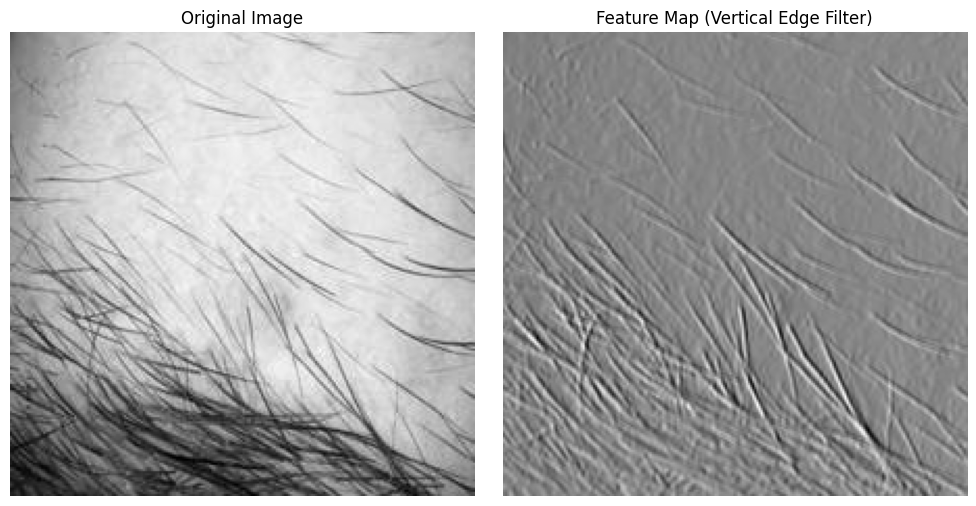

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.signal import convolve2d

img = Image.open(image_path).convert('L')   # 'L' = grayscale
image_array = np.array(img) / 255.0          # تحويل لأرقام بين 0-1

# Filter
filter = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

feature_map = convolve2d(image_array, filter, mode='valid')

# plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image_array, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(feature_map, cmap='gray')
axes[1].set_title('Feature Map')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Why Convolution Needs Far Fewer Weights Than a Dense Layer

A 200×200 grayscale image has 40,000 pixels.

**Dense layer approach:** Every pixel would need its own weight connecting to each neuron in the next layer. For just 64 neurons, that's 40,000 × 64 = 2,560,000 weights — for one layer, on one small image.

**Convolution approach:** A single 3×3 filter has only 9 weights (plus 1 bias = 10 total). This same small filter slides across the entire image, reusing the exact same 9 weights at every position — whether the image is 200×200 or 2,000×2,000, the filter size never changes.

**Why this works:** Dense layers assume every pixel's relationship to the output is unique and must be learned separately. Convolution assumes something more realistic about images: a meaningful pattern (an edge, a curve, a border) looks the same mathematically no matter where it appears in the image. So instead of learning a separate detector for "edge at position (10,10)" and another for "edge at position (150,150)," one filter learns to detect "edge" in general, and reuses that knowledge everywhere — this is **parameter sharing**.

The result: a Conv2D layer with 32 filters of size 3×3 on an RGB image needs only (3×3×3 + 1) × 32 = 896 weights, regardless of whether the image is small or huge — compared to millions for an equivalent Dense layer.

## Architecture Decision — Sprint 2

**Project data type:** Images (Melanoma Skin Cancer Dataset — Benign vs Malignant skin lesion photos).

**Decision:** CNN (Convolutional Neural Network).

**Reasoning:**
- The data consists of images, where spatial structure matters (the shape, border irregularity, and texture of a lesion — not just isolated pixel values — determine malignancy).
- A Dense network (used in Week 6 for the tabular medical dataset) would require millions of weights for even a small image and would ignore spatial relationships between neighboring pixels entirely.
- CNNs use parameter sharing and translation invariance to detect relevant patterns (edges → shapes → lesion characteristics) efficiently, regardless of where they appear in the image — making CNN the correct architecture for this sprint's data type.

**Note:** the Week 6 baseline (Logistic Regression, 0.792 accuracy) was built on the tabular dataset and is not a valid comparison point for this new image-based task. A new baseline will need to be established on the image dataset before evaluating the CNN's improvement.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/BinXtraining
!git pull origin main

import os
os.makedirs("Week7/Day1", exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/BinXtraining
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 2), reused 4 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.80 KiB | 26.00 KiB/s, done.
From https://github.com/Nour-Tamimi/BinXtraining
 * branch            main       -> FETCH_HEAD
   a6b0056..32d7913  main       -> origin/main
Updating a6b0056..32d7913
Fast-forward
 Week6/README.md | 26 ++++++++++++++++++++++++++
 1 file changed, 26 insertions(+)
 create mode 100644 Week6/README.md


In [19]:
readme_content = """Week 7, Day 1 Summary — Sprint 2 Kickoff & Convolution
What I Learned

1. Why Dense networks fail on images A 200×200 color image has 120,000 numbers. Feeding that into a Dense layer would require millions of weights just for the first layer — computationally hopeless, and it throws away a key fact about images: nearby pixels are related, and a pattern (an edge, a shape) means the same thing wherever it appears.

2. Convolution — the core idea A convolution slides a small filter (kernel, e.g. 3×3) across the image, computing a dot product at each position — the same dot product from Week 2, applied locally and repeatedly. Each filter learns to detect one specific pattern (an edge, a curve, a texture). The output is a feature map showing where that pattern was found in the image.

3. Why convolution wins over Dense layers

Parameter sharing: the same small filter (e.g. just 9 weights for a 3×3 filter) is reused across the entire image, instead of needing a separate weight for every pixel.
Translation invariance: because the filter slides everywhere, a pattern is detected no matter where it appears in the image.

4. The hierarchy a CNN learns on its own Early layers detect simple patterns (edges). Middle layers combine those into shapes and textures. Deep layers recognize whole objects or complex patterns (e.g. an irregular lesion border). Each layer works on the feature maps of the layer before it, not the raw image — this is how complexity builds up automatically through training, without hand-designing any of it.

5. Padding (valid vs same) Without padding (valid), the filter can't fully cover pixels at the image edges, so the output feature map is slightly smaller than the input. With padding (same), a border is added so the output keeps the same size as the input.

6. Normalizing image pixels (0–255 → 0–1) Same purpose as StandardScaler in Week 6: keeps all input values on a small, consistent scale, which makes training faster and more stable — without it, large raw pixel values (up to 255) can destabilize training, similar to the exploding-gradient issue seen with a high learning rate in Week 6.

What I Did Today
Reviewed Sprint 1 (Week 6) results and confirmed no serious overfitting occurred — a small, stable gap between training and validation, with Dropout/BatchNorm added as a precaution that also improved test performance.
Completed Sprint 2 planning: the project shifts from the tabular medical dataset to a new image dataset (Melanoma Skin Cancer — Benign vs Malignant), since the data type calls for a CNN, not the Dense network used in Week 6.
Applied a hand-defined edge-detection filter (3×3) to a sample image using convolution, and visualized the resulting feature map — clearly saw the filter highlight the irregular border of the shape while ignoring flat, unchanging regions.
Documented in Markdown why parameter sharing makes a CNN need far fewer weights than an equivalent Dense layer.
Confirmed and recorded the architecture decision: CNN, since the project now works with image data.
Wrote the Sprint 2 backlog (data prep, EDA on images, new image baseline, CNN build, training/evaluation, tuning, documentation).
Key Takeaway

A CNN is not "a better neural network" in general — it's the right tool specifically because the data is images with spatial structure. The Week 6 Logistic Regression baseline (0.792 accuracy) does not carry over to this new image-based task; a new baseline needs to be established before the CNN's improvement can be measured fairly.
"""

with open("Week7/Day1/README.md", "w") as f:
    f.write(readme_content)

print("File Created")

File Created


In [32]:
!git config --global user.email "nourtamimi61@gmail.com"
!git config --global user.name "Nour-Tamimi"

In [33]:
!git add .
!git commit -m "Add Week7 Day1"
!git push origin main

On branch main
Your branch is ahead of 'origin/main' by 1 commit.
  (use "git push" to publish your local commits)

nothing to commit, working tree clean
fatal: could not read Username for 'https://github.com': No such device or address


In [31]:
!git push origin main

fatal: could not read Username for 'https://github.com': No such device or address
